In [12]:
import pandas as pd

# Load both sheets
df_2010 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")
df_2011 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

# Combine both
df = pd.concat([df_2010, df_2011])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
df.columns = df.columns.str.strip()   # remove spaces

df.rename(columns={
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice'
}, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1067371 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   UnitPrice    1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 73.3+ MB


In [10]:
import os
os.listdir()

['.vimrc',
 'cleaned_marketing_dataset.xlsx',
 '.bashrc',
 '.pythonstartup.py',
 '.virtualenvs',
 '.ipynb_checkpoints',
 '.jupyter',
 'anaconda_projects',
 'online_retail_II.xlsx',
 '.conda',
 '.profile',
 '.npm',
 'README.ipynb',
 'project2.ipynb',
 '.ipython',
 'project1.ipynb',
 '.local',
 '.anaconda',
 '.gitconfig',
 'project1_marketing_raw_dataset.xlsx']

In [16]:
# Remove missing
df = df.dropna(subset=['Customer ID']).copy()   # .copy() avoids SettingWithCopyWarning

# Convert datatype
df['Customer ID'] = df['Customer ID'].astype(int)

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove negative or zero values
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]      # <-- was 'UnitPrice', column is actually 'Price'

In [18]:
df['Revenue'] = df['Quantity'] * df['Price']

In [20]:
total_customers = df['Customer ID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 5878


In [21]:
customers_country = df.groupby('Country')['Customer ID'].nunique().sort_values(ascending=False)
print(customers_country.head())

Country
United Kingdom    5350
Germany            107
France              95
Spain               41
Belgium             29
Name: Customer ID, dtype: int64


In [22]:
total_orders = df['Invoice'].nunique()
print("Total Orders:", total_orders)

Total Orders: 36969


In [23]:
orders_per_customer = df.groupby('Customer ID')['Invoice'].nunique()
print(orders_per_customer.describe())

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64


In [24]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 17743429.178000003


In [25]:
revenue_per_customer = df.groupby('Customer ID')['Revenue'].sum()
print(revenue_per_customer.describe())

count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
25%         348.762500
50%         898.915000
75%        2307.090000
max      608821.650000
Name: Revenue, dtype: float64


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='YearMonth'>

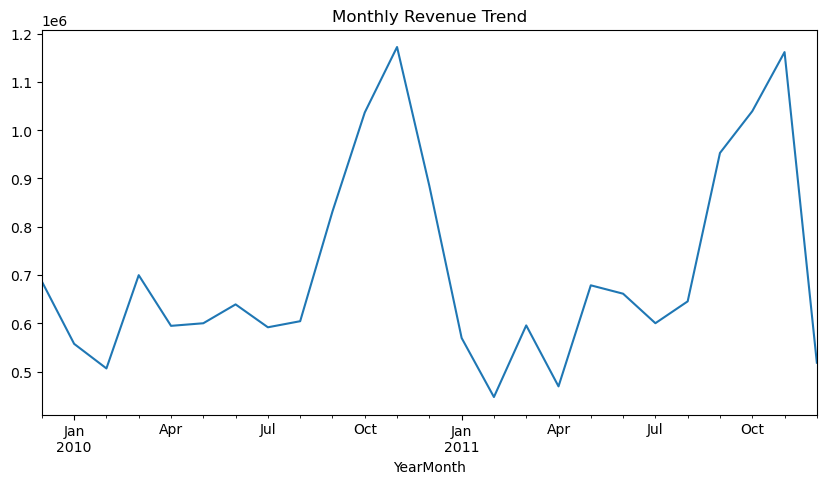

In [26]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

monthly_revenue.plot(figsize=(10,5), title="Monthly Revenue Trend")

In [27]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                152340.57
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
POSTAGE                               126563.04
PARTY BUNTING                         103880.23
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79594.33
Name: Revenue, dtype: float64
